In [1]:
%cd /home/govind/gov_semproject/GridCellsCopy

/home/govind/gov_semproject/GridCellsCopy


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import g_utils
import analysis_utils as a_utils
from interneuron import Interneuron
import sim_utils as s_utils
from neuron import h
import importlib
import seaborn as sns
import pandas as pd
importlib.reload(g_utils)
h.load_file("stdrun.hoc")
h.celsius=37
#h.cvode_active(1)

In [8]:
test_interneuron = Interneuron(0)

def f_i_const_curr(curr_amp,time_ms,sigma=50,osc_amp=0):
    
    ic = h.IClamp(test_interneuron.soma(0.5))
    #ic.delay=0
    ic.dur = 1e9
    freq=40
    
    #ic_amp = curr_amp
    T,num_steps = time_ms/1000, time_ms
    time_arr = np.linspace(0,T,num_steps)
    curr_arr = np.full(time_arr.shape,curr_amp)
    theta_arr = osc_amp*np.sin(2*np.pi*freq*time_arr)
    curr_vec = h.Vector(curr_arr+theta_arr)
    
    curr_vec.play(ic, ic._ref_amp, True)
    rec_i = h.Vector().record(ic._ref_amp)
    rec_v = h.Vector().record(test_interneuron.soma(0.5)._ref_v)
    rec_t = h.Vector().record(h._ref_t)
    spike_times = h.Vector()

    nc = h.NetCon(test_interneuron.soma(0.5)._ref_v, None, sec=test_interneuron.soma)
    nc.threshold=0
    nc.record(spike_times)

    h.finitialize(-70)
    h.continuerun(time_ms)

    np_spike_array = np.array(spike_times.to_python())
    print(np_spike_array)
    firing_rate = a_utils.instant_rate(spike_train=spike_times,sim_dur=time_ms,stdev=sigma)*1000 #converting to Hz
    
    del nc,ic,spike_times
    #g_utils.plot_power_spectrum(firing_rate,xmax=500)
    return np.mean(firing_rate), np.std(firing_rate),np_spike_array

    

osc_amp_list = [i*1e-3 for i in range(0,20,1)]
freq_mean_list=[]
freq_std_list =[]
spikes_list=[]
for amp in osc_amp_list:
    print(f"Current : {amp}nA")
    mean,std,spikes = f_i_const_curr(curr_amp=1e-2,time_ms=10000,sigma=20,osc_amp=amp)
    freq_mean_list.append(mean)
    freq_std_list.append(std)
    spikes_list.append(spikes)

data = {'input':[cur*1000 for cur in osc_amp_list],
        'mean':freq_mean_list,
        'std':freq_std_list,
        'spikes':spikes_list}

df = pd.DataFrame(data)




Current : 0.0nA
[2.125000e+00 5.825000e+00 9.400000e+00 ... 9.990200e+03 9.993675e+03
 9.997150e+03]
Current : 0.001nA
[  13.525        17.4          21.2        ... 9989.55000002 9993.20000002
 9996.85000002]
Current : 0.002nA
[2.075000e+00 5.725000e+00 9.050000e+00 ... 9.990125e+03 9.994000e+03
 9.997775e+03]
Current : 0.003nA
[2.050000e+00 5.350000e+00 8.450000e+00 ... 9.988850e+03 9.992875e+03
 9.996950e+03]
Current : 0.004nA
[2.050000e+00 5.250000e+00 8.250000e+00 ... 9.990450e+03 9.994975e+03
 9.998925e+03]
Current : 0.005nA
[  23.225        26.875        29.925      ... 9987.72500002 9992.05000002
 9996.85000002]
Current : 0.006nA
[2.000000e+00 5.050000e+00 7.875000e+00 ... 9.987500e+03 9.992025e+03
 9.997275e+03]
Current : 0.007nA
[2.000000e+00 4.975000e+00 7.700000e+00 ... 9.987950e+03 9.993325e+03
 9.998375e+03]
Current : 0.008nA
[  20.625        25.3          28.4        ... 9986.12500002 9990.15000002
 9997.40000002]
Current : 0.009000000000000001nA
[1.950000e+00 4.825000e+

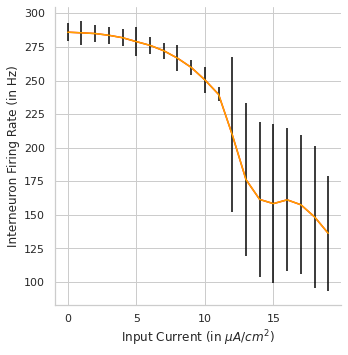

In [9]:
sns.set_theme(font='monospace')
sns.set(style='whitegrid')

sns.relplot(x='input',y='mean',data=df,kind='line',markers=True,color='red')
plt.errorbar(df['input'],df['mean'],yerr=df['std'],color='orange',ecolor='black')
plt.xlabel("Input Current (in $\mu A/cm^2$)")
plt.ylabel("Interneuron Firing Rate (in Hz)")
plt.savefig("INTRNR_FIRING_RATE.png",dpi=600)
plt.show()